In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, SimpleRNN, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

In [2]:
# Load dataset
(XTrain, yTrain), (XTest, yTest) = fashion_mnist.load_data()

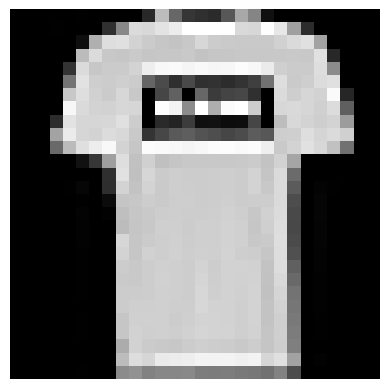

In [3]:
# Displaying a pickture from the dataset
plt.imshow(XTrain[1], cmap='gray')
plt.axis('off')
plt.show()

In [4]:
# Reshape inte input data for the cnn
XTrainCnn = XTrain.reshape(-1, 28, 28, 1)
XTestCnn = XTest.reshape(-1, 28, 28, 1)

# Normalizing the images
XTrain = XTrain / 255.0
XTest = XTest / 255.0

# One-hot encoding of labels
yTrainCategorical = to_categorical(yTrain)

In [5]:
# Define Early Stopping
earlyStopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

In [6]:
# Model 1: Convolutional Neural Network (CNN)
modelCnn = Sequential([
    Conv2D(20, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    Conv2D(20, kernel_size=(3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
modelCnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model 2: Fully Connected Neural Network (FCNN)
modelFcnn = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
modelFcnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model 3: Simple RNN
modelRnn = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(28, 28)),
    SimpleRNN(64),
    Dense(10, activation='softmax')
])
modelRnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [7]:
modelCnn.fit(XTrainCnn, yTrainCategorical, epochs=3, batch_size=64, validation_split = 0.2)

Epoch 1/3
750/750 [==============================] - 79s 101ms/step - loss: 1.1834 - accuracy: 0.8358 - val_loss: 0.3609 - val_accuracy: 0.8652
Epoch 2/3
750/750 [==============================] - 69s 92ms/step - loss: 0.2709 - accuracy: 0.9004 - val_loss: 0.3213 - val_accuracy: 0.8860
Epoch 3/3
750/750 [==============================] - 66s 88ms/step - loss: 0.1985 - accuracy: 0.9252 - val_loss: 0.3499 - val_accuracy: 0.8847


In [8]:
modelFcnn.fit(XTrain, yTrainCategorical, epochs=30, batch_size=64, validation_split = 0.2, callbacks=[earlyStopping])

Epoch 1/30
750/750 [==============================] - 4s 5ms/step - loss: 0.5418 - accuracy: 0.8093 - val_loss: 0.4417 - val_accuracy: 0.8457
Epoch 2/30
750/750 [==============================] - 3s 4ms/step - loss: 0.3882 - accuracy: 0.8598 - val_loss: 0.3707 - val_accuracy: 0.8676
Epoch 3/30
750/750 [==============================] - 4s 5ms/step - loss: 0.3478 - accuracy: 0.8738 - val_loss: 0.3580 - val_accuracy: 0.8690
Epoch 4/30
750/750 [==============================] - 5s 7ms/step - loss: 0.3195 - accuracy: 0.8814 - val_loss: 0.3358 - val_accuracy: 0.8789
Epoch 5/30
750/750 [==============================] - 3s 4ms/step - loss: 0.3007 - accuracy: 0.8899 - val_loss: 0.3843 - val_accuracy: 0.8553
Epoch 6/30
750/750 [==============================] - 4s 5ms/step - loss: 0.2875 - accuracy: 0.8927 - val_loss: 0.3336 - val_accuracy: 0.8768
Epoch 7/30
750/750 [==============================] - 5s 6ms/step - loss: 0.2717 - accuracy: 0.8983 - val_loss: 0.3453 - val_accuracy: 0.8777
Epoch 

In [9]:
modelRnn.fit(XTrain, yTrainCategorical, epochs=30, batch_size=64, validation_split = 0.2, callbacks=[earlyStopping])

Epoch 1/30
750/750 [==============================] - 15s 18ms/step - loss: 0.7799 - accuracy: 0.7171 - val_loss: 0.6063 - val_accuracy: 0.7833
Epoch 2/30
750/750 [==============================] - 13s 18ms/step - loss: 0.5310 - accuracy: 0.8087 - val_loss: 0.5065 - val_accuracy: 0.8207
Epoch 3/30
750/750 [==============================] - 13s 18ms/step - loss: 0.4797 - accuracy: 0.8277 - val_loss: 0.4546 - val_accuracy: 0.8362
Epoch 4/30
750/750 [==============================] - 13s 18ms/step - loss: 0.4564 - accuracy: 0.8369 - val_loss: 0.4457 - val_accuracy: 0.8422
Epoch 5/30
750/750 [==============================] - 12s 15ms/step - loss: 0.4355 - accuracy: 0.8451 - val_loss: 0.4872 - val_accuracy: 0.8253
Epoch 6/30
750/750 [==============================] - 12s 16ms/step - loss: 0.4281 - accuracy: 0.8475 - val_loss: 0.4700 - val_accuracy: 0.8341
Epoch 7/30
750/750 [==============================] - 14s 18ms/step - loss: 0.4159 - accuracy: 0.8522 - val_loss: 0.4059 - val_accuracy:

In [10]:
fashionMnistLabels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Evaluate individual models
def evaluateModel(model, XTest, yTest, predictions, model_name='Model'):
    predictions = np.argmax(predictions, axis=1)
    generatedReport = classification_report(yTest, predictions, target_names=fashionMnistLabels, output_dict=True)
    return {
        "Model": model_name,
        "Accuracy": generatedReport['accuracy'],
        "Precision": generatedReport['macro avg']['precision'],
        "Recall": generatedReport['macro avg']['recall'],
        "F1-Score": generatedReport['macro avg']['f1-score']
    }

In [11]:
# Committee Decision
predictionsCnn = modelCnn.predict(XTestCnn)
predictionsFcnn = modelFcnn.predict(XTest)
predictionsRnn = modelRnn.predict(XTest)

# Evaluate individual models and collect results
results = []
results.append(evaluateModel(modelCnn, XTestCnn, yTest, predictionsCnn, "CNN"))
results.append(evaluateModel(modelFcnn, XTest, yTest, predictionsFcnn, "FCNN"))
results.append(evaluateModel(modelRnn, XTest, yTest, predictionsRnn, "RNN"))

# Evaluate committee
final_predictions = np.argmax((predictionsCnn + predictionsFcnn + predictionsRnn) / 3, axis=1)
generatedCommitteeReport = classification_report(yTest, final_predictions, target_names=fashionMnistLabels, output_dict=True)
results.append({
    "Model": "Committee",
    "Accuracy": generatedCommitteeReport['accuracy'],
    "Precision": generatedCommitteeReport['macro avg']['precision'],
    "Recall": generatedCommitteeReport['macro avg']['recall'],
    "F1-Score": generatedCommitteeReport['macro avg']['f1-score']
})

# Create DataFrame and display results
results_df = pd.DataFrame(results)

313/313 [==============================] - 2s 5ms/step


In [12]:
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.8774,0.877262,0.8774,0.875703
1,FCNN,0.8814,0.884741,0.8814,0.882410
2,RNN,0.8537,0.855184,0.8537,0.853080
3,Committee,0.8940,0.893889,0.8940,0.893457
